---------DAY-3---------

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder ,  StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings 
warnings.filterwarnings("ignore")

PROGRAM-1

RMSE Data type : <class 'numpy.float64'>
R2 data type :  <class 'float'>
Root Mean Squared Error (RMSE): 4.9286
R2 Score: 0.6688


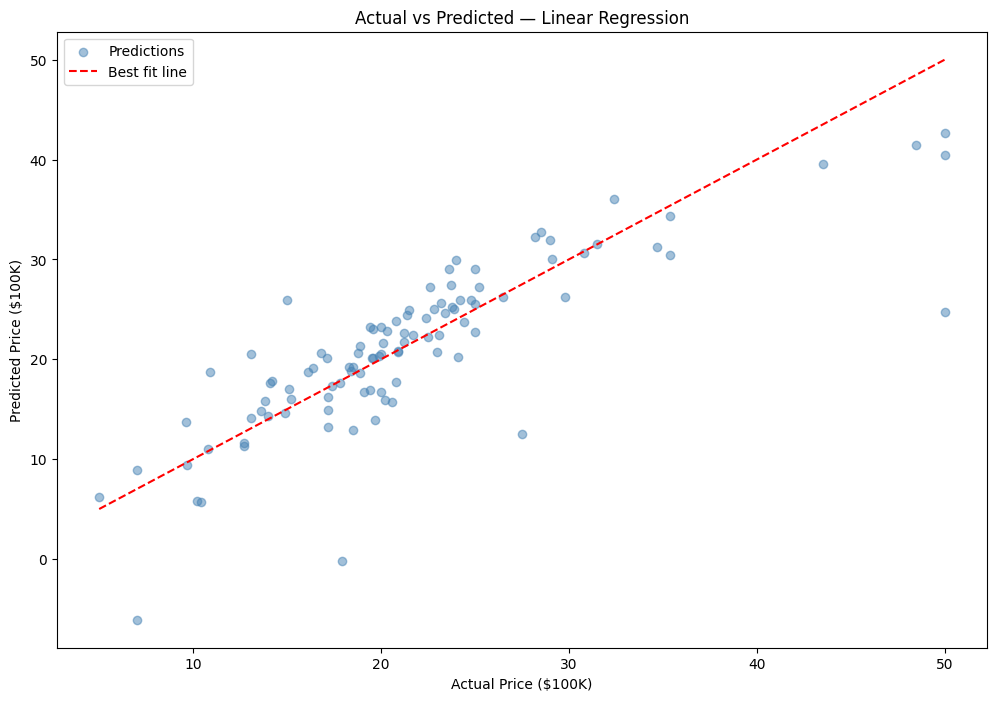

In [2]:
#Train Linear Regression on Boston Housing dataset; evaluate RMSE & R² 
#Load  Boston Housing dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)
# Features and target
X = boston.data.apply(pd.to_numeric)
y = pd.to_numeric(boston.target)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print("RMSE Data type :" , type(rmse))
print("R2 data type : " , type(r2))
print("Root Mean Squared Error (RMSE):", rmse.round(4))
print("R2 Score:", r2.__round__(4))
#visulise through graph
plt.figure(figsize=(12, 8))
plt.scatter(y_test , y_pred , alpha = 0.5 , color = 'steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Best fit line')
plt.xlabel("Actual Price ($100K)")
plt.ylabel("Predicted Price ($100K)")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.show()

# INTERPRETATION:
# • If all dots lie on the red line → perfect model
# • Dots spread away from the line → prediction errors

PROGRAM-2

Class distribution: [100  50]
Coefficients (weights): [[-2.38791011 -2.09062933]]
Intercept: [-2.60638646]

First 10 predicted labels: [0 1 0 0 0 1 0 0 0 0]
First 10 probabilities: [0.018 0.933 0.    0.01  0.009 0.933 0.06  0.    0.01  0.053]


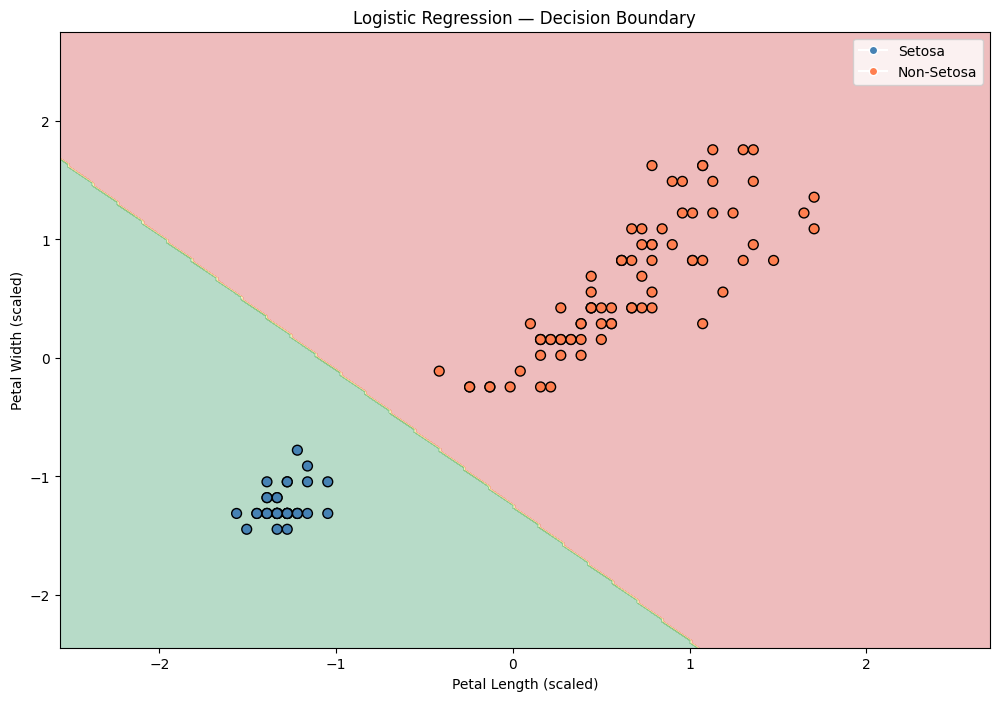

In [3]:
#Train Logistic Regression on Iris (binary: setosa vs non-setosa)
# Load Iris dataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
iris = load_iris()

# Features
X = iris.data    # 4 features: sepal_length, sepal_width, petal_length, petal_width
y_multi = iris.target   # 0=Setosa, 1=Versicolor, 2=Virginica
# Convert to binary: Setosa(0) = 1, everything else = 0
y = (y_multi == 0).astype(int)
print("Class distribution:", np.bincount(y))

# Use only 2 features for easy visualisation
# Petal length (index 2) and petal width (index 3) work best
X_vis = X[:, [2, 3]]  

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_vis, y, test_size=0.2, random_state=42)

# Feature Scaling — VERY IMPORTANT for Logistic Reg
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test  = scaler.transform(X_test)       # only transform on test (no data leak!)

#Train Logistic Regression
clf = LogisticRegression(random_state=42, max_iter=200)
clf.fit(X_train, y_train)
print("Coefficients (weights):", clf.coef_)
print("Intercept:", clf.intercept_)

#Predictions
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]  # probability of being Setosa

print("\nFirst 10 predicted labels:", y_pred[:10])
print("First 10 probabilities:", y_prob[:10].round(3))

#  Plot Decision Boundary
h = 0.02   # Step size for mesh grid
x_min, x_max = X_train[:, 0].min()-1, X_train[:, 0].max()+1
y_min, y_max = X_train[:, 1].min()-1, X_train[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for every point in the mesh grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(12 , 8))
plt.contourf(xx , yy , Z , alpha=0.3 , cmap='RdYlGn')  # shaded regions

# Plot actual training points
colors = ['coral' if label==0 else 'steelblue' for label in y_train]
plt.scatter(X_train[:, 0], X_train[:, 1]  , c=colors, edgecolors='k', s=50, label='Training points')

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Logistic Regression — Decision Boundary")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o' , color='w' , markerfacecolor='steelblue', label='Setosa'),
    plt.Line2D([0],[0], marker='o' , color='w' , markerfacecolor='coral', label='Non-Setosa')])
plt.show()

PROGRAM-3

Accuracy: 1.0

Confusion Matrix:
[[20  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



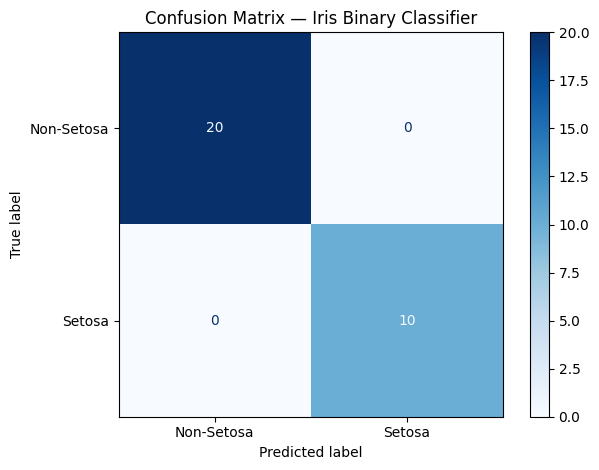

In [4]:
#Print classification report and confusion matrix 
# Load Iris dataset
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              accuracy_score)
iris = load_iris()

# Features
X = iris.data

# Create binary target:
# 1 = Setosa, 0 = Non-Setosa
y = (iris.target == 0).astype(int)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualise it with a nice heatmap
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Setosa', 'Setosa'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Iris Binary Classifier")
plt.tight_layout()
plt.show()

PROGRAM-4

In [5]:
#Plot actual vs predicted values for regression
#visulise through graph of program 1

PRACTICE SHEET

PROGRAM-5

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Hours_Studied :  [[5.5]]
Student is predicted to PASS.


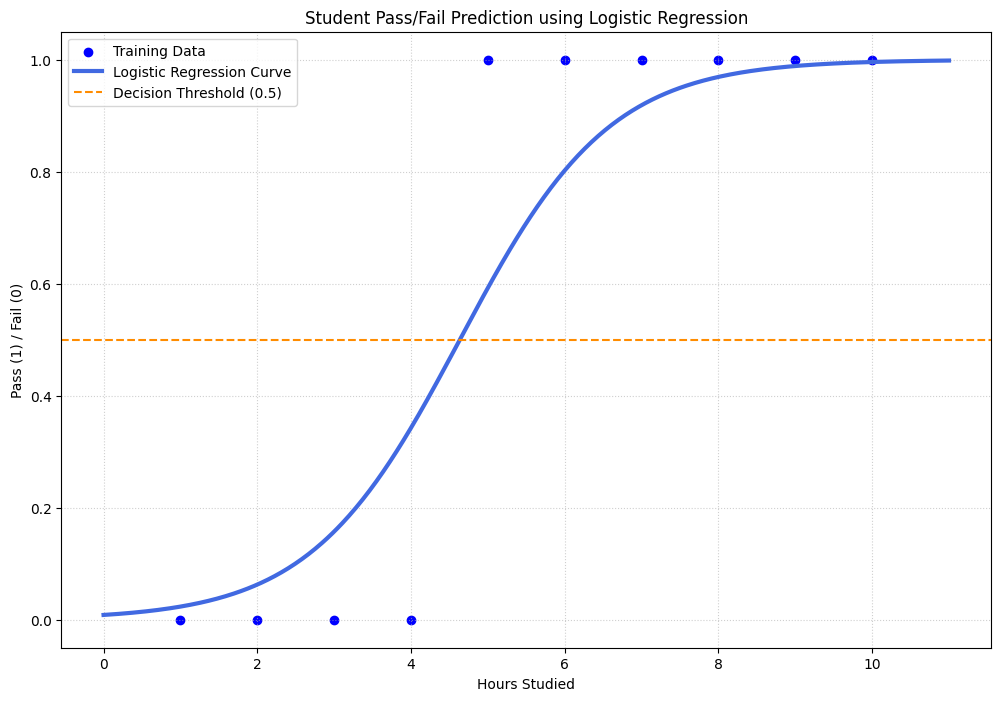

In [6]:
# Predict student exam pass/fail using logistic regression 
# Create sample dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Pass':           [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features and target
X = df[['Hours_Studied']]
y = df['Pass']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict for a new student
hours = [[5.5 ]]
print("Hours_Studied : " , (hours))
prediction = model.predict(hours)
if prediction[0] == 1:
   print("Student is predicted to PASS.")
else:
   print("Student is predicted to FAIL.")

# Plot
plt.figure(figsize=(12 , 8))
plt.scatter(df['Hours_Studied'] , df['Pass'] , color='blue' , label='Training Data')

# Generate Continuous Points for a Smooth Line Plot
X_smooth = np.linspace(0, 11, 500).reshape(-1, 1)

# Predict probabilities for the smooth line (gives [prob_fail, prob_pass])
y_prob_smooth = model.predict_proba(X_smooth)[:, 1]

# Plot the logistic regression curve
plt.plot(X_smooth, y_prob_smooth, color="royalblue", linewidth=3, label="Logistic Regression Curve")
# Plot decision threshold line at 0.5 probability
plt.axhline(0.5, color="darkorange", linestyle="--", linewidth=1.5, label="Decision Threshold (0.5)")

plt.xlabel("Hours Studied")
plt.ylabel("Pass (1) / Fail (0)")
plt.title("Student Pass/Fail Prediction using Logistic Regression")
plt.grid(True, linestyle=':', alpha=0.6 )
plt.legend()
plt.show()


PROGRAM-6

Train/Test Split  Train Accuracy  Test Accuracy
           90/10        0.911111          0.860
           80/20        0.905000          0.900
           70/30        0.908571          0.900
           60/40        0.923333          0.905


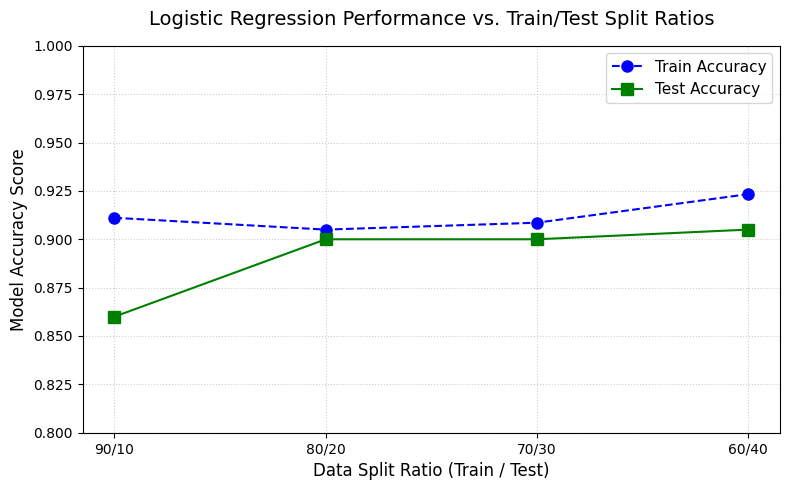

In [7]:
# Compare predictions for different train/test split ratios 

# Set seed for reproducibility
np.random.seed(42)

# Generate 500 samples
n_samples = 500
study_hours = np.random.uniform(1, 20, n_samples)
attendance = np.random.uniform(50, 100, n_samples)

# Define a decision boundary with some random noise
noise = np.random.normal(0, 10, n_samples)
score = (2.5 * study_hours) + (0.8 * attendance) - 65 + noise
passed = (score > 0).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Passed': passed
})

X = df[['Study_Hours', 'Attendance']]
y = df['Passed']
# Define test sizes to evaluate
test_sizes = [0.1, 0.2, 0.3, 0.4]
split_labels = ['90/10', '80/20', '70/30', '60/40']

train_accuracies = []
test_accuracies = []

for test_size in test_sizes:
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Scale features for stable logistic regression convergence
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Logistic Regression
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)
    
    # Predict and calculate accuracies
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# Display tabular summary
results_df = pd.DataFrame({
    'Train/Test Split': split_labels,
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})
print(results_df.to_string(index=False))


# Vasualise through plot
plt.figure(figsize=(8, 5))
plt.plot(split_labels, train_accuracies, marker='o', markersize=8, linestyle='--', color='blue', label='Train Accuracy')
plt.plot(split_labels, test_accuracies, marker='s', markersize=8, linestyle='-', color='green', label='Test Accuracy')
plt.title('Logistic Regression Performance vs. Train/Test Split Ratios', fontsize=14, pad=15)
plt.xlabel('Data Split Ratio (Train / Test)', fontsize=12)
plt.ylabel('Model Accuracy Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6 )
plt.legend(fontsize=11)
plt.ylim(0.80, 1.0)  
plt.tight_layout()
plt.show()
